# First Classification 🐥🐥

0. Import usual libraries

In [46]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
)
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.model_selection import cross_val_score


1. Download the following data using this link : ```https://full-stack-bigdata-datasets.s3.eu-west-3.amazonaws.com/Machine+Learning+Supervis%C3%A9/R%C3%A9gression+logistique+Cross+validation/Datasets/ex2data1.txt``` and put it into a DataFrame

Pay attention to the header of the DataFrame, there's something annoying with it! Look at the documentation of `pd.read_csv()` to find a way of solving the problem 🤓

In [3]:
data = pd.read_csv("https://full-stack-bigdata-datasets.s3.eu-west-3.amazonaws.com/Machine+Learning+Supervis%C3%A9/R%C3%A9gression+logistique+Cross+validation/Datasets/ex2data1.txt", 
                   header=None,)
data.head()

,0,1,2
0,34.623660,78.024693,0
1,30.286711,43.894998,0
2,35.847409,72.902198,0
3,60.182599,86.308552,1
4,79.032736,75.344376,1


In [4]:
data.shape

(100, 3)

2. Rename the columns using the following names : 

"Col_1" / "Col_2" / "Target"

In [6]:
data = data.rename(columns={0: "Col_1", 1: "Col_2", 2: "Target"})
data.head()

,Col_1,Col_2,Target
0,34.623660,78.024693,0
1,30.286711,43.894998,0
2,35.847409,72.902198,0
3,60.182599,86.308552,1
4,79.032736,75.344376,1


3. Visualize the data as a scatter plot where the two different classes are displayed with different colors.

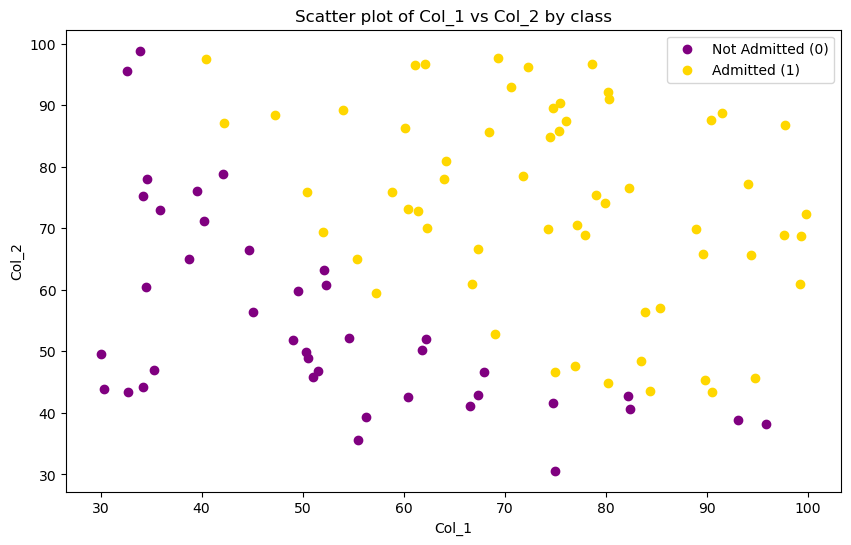

In [12]:
fig = plt.figure(figsize=(10, 6))

plt.scatter(
    data[data["Target"] == 0]["Col_1"],
    data[data["Target"] == 0]["Col_2"],
    color='purple',
    label='Not Admitted (0)'
)

plt.scatter(
    data[data["Target"] == 1]["Col_1"],
    data[data["Target"] == 1]["Col_2"],
    color='gold',
    label='Admitted (1)'
)

plt.xlabel("Col_1")
plt.ylabel("Col_2")
plt.title("Scatter plot of Col_1 vs Col_2 by class")
plt.legend()
plt.show()

4. Separate X and y into two different objects.

In [19]:
target = "Target"

X = data.loc[:, data.columns != target]
Y = data[target]
print("Y:")
print(Y.head())
print()
print("X:")
print(X.head())


Y:
0    0
1    0
2    0
3    1
4    1
Name: Target, dtype: int64

X:
       Col_1      Col_2
0  34.623660  78.024693
1  30.286711  43.894998
2  35.847409  72.902198
3  60.182599  86.308552
4  79.032736  75.344376


5. Split the data into a train set and a test set

In [20]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

6. Do you think that the two variables "Col_1" and "Col_2" would be good predictors of the target?

In [ ]:
fig = px.histogram(
    data_frame=data,
    x="Col_1",
    color="Target",
    facet_row="Target",
    histnorm="probability",
    title="Distribution of Col_1 by Target"
)

fig.show()

In [24]:
fig= px.histogram(
    data_frame=data,
    x="Col_2",
    color="Target",
    facet_row="Target",
    histnorm="probability",  
    title="Distribution of Col_2 by Target"
)
fig.show()

7. Analyze the explanatory variables, what preprocessings are necessary? Make the preprocessings.

In [30]:
data.describe(include='all')

,Col_1,Col_2,Target
count,100.000000,100.000000,100.000000
mean,65.644274,66.221998,0.600000
std,19.458222,18.582783,0.492366
min,30.058822,30.603263,0.000000
25%,50.919511,48.179205,0.000000
50%,67.032988,67.682381,1.000000
75%,80.212529,79.360605,1.000000
max,99.827858,98.869436,1.000000


In [33]:
(data.isnull().sum()/len(data))*100

Col_1     0.0
Col_2     0.0
Target    0.0
dtype: float64

Some good news:
* There are no missing values in this dataset --> no imputation needed
* Although we're dealing with a classification problem, the _Target_ is alrady encoded as 0s and 1s, so we don't need to use the LabelEncoder
* All the features (_Col1_ and _Col2_) are numeric, so we just want to apply a StandardScaler to the whole array X

In [38]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_train

array([[-0.8284396 , -0.77976382],
       [-0.67919821,  0.16568501],
       [ 0.4930195 ,  1.04527047],
       [-0.41848617, -0.36865665],
       [ 1.20995678, -0.03006152],
       [ 0.09022276, -1.26703117],
       [ 0.8430824 , -1.38663867],
       [ 0.94670182, -1.22959199],
       [-1.55877494, -0.32113757],
       [ 0.92007357, -0.54138557],
       [-0.46792916, -1.45973236],
       [-0.91921886,  1.19158515],
       [ 0.65566329,  1.63181015],
       [-0.21062227,  0.3475072 ],
       [ 1.61000621,  0.13490815],
       [-1.58934841,  1.751516  ],
       [ 0.72139694,  0.42051736],
       [ 0.44769152,  0.99598763],
       [-0.76749823, -0.89174777],
       [ 1.46888313, -1.11317751],
       [-1.17035579,  1.1176709 ],
       [-0.18798554, -0.86742048],
       [ 0.47384485, -1.92617441],
       [-0.16828293, -0.77018631],
       [-1.3070729 ,  0.52145838],
       [-0.54919109, -0.76194948],
       [ 1.71955733,  0.32387668],
       [-1.55379767,  0.62855116],
       [ 0.58325304,

8. Use the LogisticRegression function from sklearn in order to create a model instance and train it.

In [40]:
classifier = LogisticRegression()
classifier.fit(X_train, Y_train)

LogisticRegression()

In [42]:
Y_train_pred = classifier.predict(X_train)
Y_train_proba = classifier.predict_proba(X_train)

In [43]:
Y_test_pred = classifier.predict(X_test)
Y_test_proba = classifier.predict_proba(X_test)

9. What's the accuracy on the train set ? and on the test set ?

Find a way of evaluating the scores without explicitely computing the model's predictions.

In [44]:
print(accuracy_score(Y_train, Y_train_pred))
print(accuracy_score(Y_test, Y_test_pred))

0.875
0.95


10. What's the average score with a cross-validation using K=10, what's the score's standard deviation?

In [47]:
scores = cross_val_score(classifier, X, Y, cv=10)
print("Cross-validated accuracy :", scores.mean())
print("Standard deviation :", scores.std())


Cross-validated accuracy : 0.89
Standard deviation : 0.05385164807134503


11. Is the model underfitting/overfitting?

12. Create objects containing the model's predictions on the train/test sets, as well as the estimated probabilities

In [52]:
Y_train_pred = classifier.predict(X_train)
Y_train_proba = classifier.predict_proba(X_train)
print(Y_train_pred[:5])
print(Y_train_proba[:5])


[0 0 1 0 1]
[[0.9091756  0.0908244 ]
 [0.5510213  0.4489787 ]
 [0.01891173 0.98108827]
 [0.65836477 0.34163523]
 [0.03075805 0.96924195]]


In [53]:
Y_test_pred = classifier.predict(X_test)
Y_test_proba = classifier.predict_proba(X_test)
print(Y_test_pred[:5])
print(Y_test_proba[:5])


[1 1 1 1 0]
[[0.0138547  0.9861453 ]
 [0.0255437  0.9744563 ]
 [0.03623478 0.96376522]
 [0.1085291  0.8914709 ]
 [0.69803519 0.30196481]]


13. Display the confusion matrix derived from the predictions performed by your model on the training data, do the same on your test data. What do you think of your model's performance, do you think it would generalize well on unknown data?

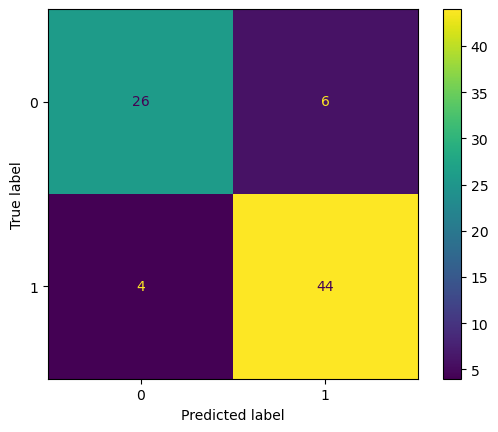

In [55]:
ConfusionMatrixDisplay.from_estimator(
    classifier,
    X_train,
    Y_train,
)
plt.show()

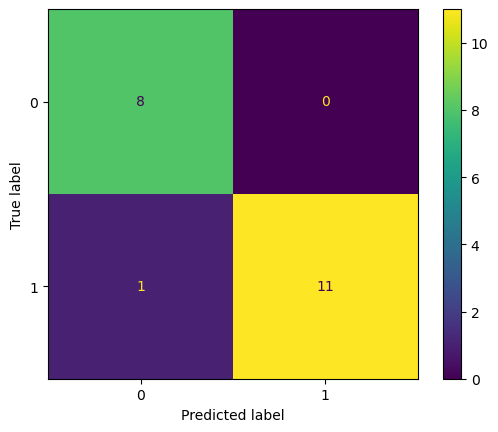

In [56]:
ConfusionMatrixDisplay.from_estimator(
    classifier,
    X_test,
    Y_test,
)
plt.show()

**From the questions above, we can deduce that the generalized performances are very good ! Indeed, the test accuracy is comparable to the train accuracy and we can see in the confusion matrix that the prediction errors are very rare 🥳🥳**

14. Produce the ROC curve for the train set and the test set

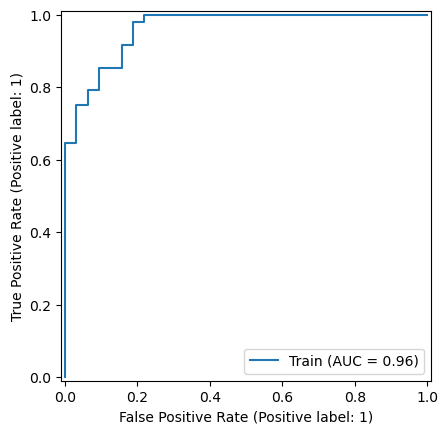

In [57]:
RocCurveDisplay.from_estimator(
    classifier,
    X_train,
    Y_train,
    name="Train",
)

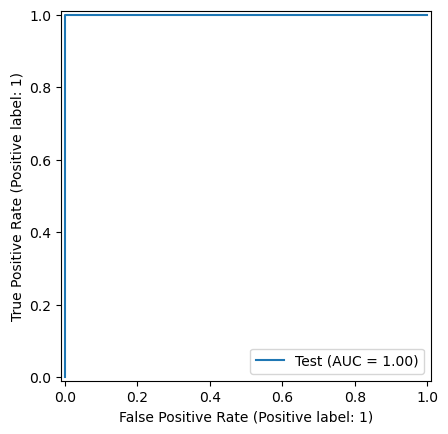

In [58]:
RocCurveDisplay.from_estimator(
    classifier,
    X_test,
    Y_test,
    name="Test",
)

**The area under the curves is quite close to 1. This means that the model is robust as it does not depend on the choice of the threshold used in the logistic regression.**

15. Create a DataFrame named predictions_df_train that contains the following values on train set:
* explanatory variables "Col_1" and "Col_2"
* the target variable Y
* the predictions Y_pred 
* the estimated probabilites from the classifier. 

Sort the values according to the probabilities (in ascending order).

In [62]:
predictions_df_train = pd.DataFrame(X_train, columns = ['Col_1', 'Col_2'])
predictions_df_train["Y"] = Y_train.tolist()
predictions_df_train["Y_pred"] = Y_train_pred.tolist()
predictions_df_train["Proba"] = Y_train_proba[:, 1].tolist()
predictions_df_train = predictions_df_train.sort_values(by="Proba")
predictions_df_train.head()

,Col_1,Col_2,Y,Y_pred,Proba
66,-1.771519,-1.210111,0,0,0.005923
44,-1.649222,-1.241779,0,0,0.007231
59,-1.782960,-0.903145,0,0,0.010260
45,-0.506668,-1.658564,0,0,0.036487
8,-1.558775,-0.321138,0,0,0.047638


16. Plot the probabilities as a function of the variables "Col_1" and "Col_2". Change the marker color according to the values of "Y_pred".

In [63]:
fig = px.scatter_3d(predictions_df_train, x = 'Col_1', y = 'Col_2', z = 'Proba', title = "training set", color = 'Y_pred')
fig.show()

17. Use the library mlxtend to plot the decision boundary of the model. You might need to install it before : 
```python
!pip install mlxtend
```
This documentation page might help you 😉 : http://rasbt.github.io/mlxtend/api_subpackages/mlxtend.plotting/

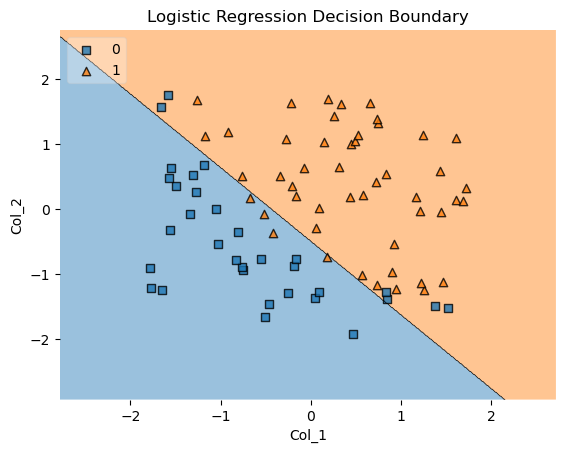

In [65]:
from mlxtend.plotting import plot_decision_regions

X = predictions_df_train.iloc[:,:2].values
Y = predictions_df_train.loc[:,"Y"].values

# Plotting decision regions
plot_decision_regions(X, Y, clf=classifier, legend=2)

# Adding axes annotations
plt.xlabel('Col_1')
plt.ylabel('Col_2')
plt.title('Logistic Regression Decision Boundary')
plt.show()
